<a href="https://colab.research.google.com/github/Sampritisahoo/Detect-tumors-from-MRI-images-using-Deep-Learning-CNN-Transfer-Learning-./blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
pip install tensorflow opencv-python matplotlib seaborn scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 38.1 MB/s eta 0:00:00


In [31]:
!pip show streamlit

Name: streamlit
Version: 1.57.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: altair, anyio, blinker, cachetools, click, gitpython, httptools, itsdangerous, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, python-multipart, requests, starlette, tenacity, toml, typing-extensions, uvicorn, watchdog, websockets
Required-by: 


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 938s 3s/step - accuracy: 0.4179 - loss: 1.2503 - val_accuracy: 0.5321 - val_loss: 1.1059
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 933s 3s/step - accuracy: 0.4982 - loss: 1.1068 - val_accuracy: 0.5348 - val_loss: 1.0500
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 933s 3s/step - accuracy: 0.5214 - loss: 1.0898 - val_accuracy: 0.5982 - val_loss: 0.9762
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 942s 3s/step - accuracy: 0.5431 - loss: 1.0461 - val_accuracy: 0.5562 - val_loss: 0.9946
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 938s 3s/step - accuracy: 0.5496 - loss: 1.0207 - val_accuracy: 0.5857 - val_loss: 0.9542
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 935s 3s/step - accuracy: 0.5650 - loss: 1.0085 - val_accuracy: 0.5071 - val_loss: 0.9772
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 992s 3s/step - accuracy: 0.5509 - loss: 1.0093 - va

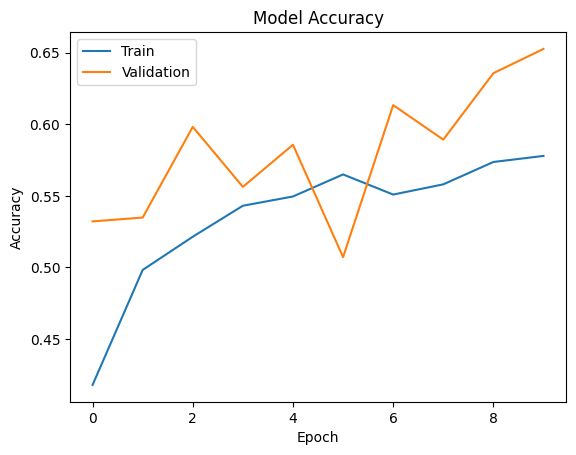

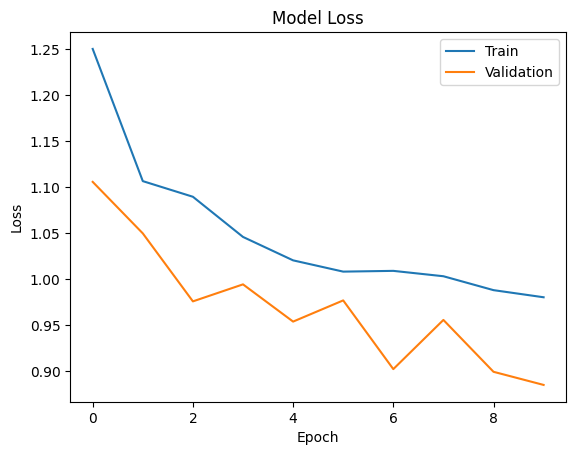

70/70 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step


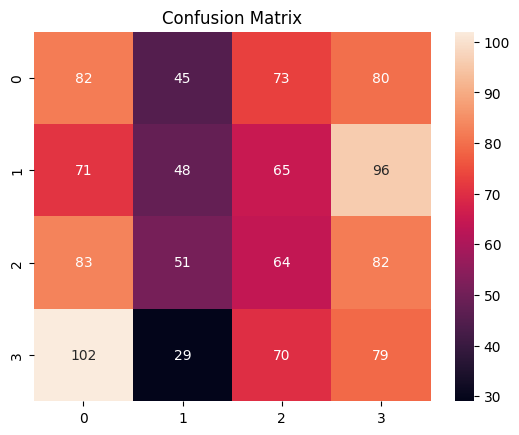

              precision    recall  f1-score   support

           0       0.24      0.29      0.27       280
           1       0.28      0.17      0.21       280
           2       0.24      0.23      0.23       280
           3       0.23      0.28      0.26       280

    accuracy                           0.24      1120
   macro avg       0.25      0.24      0.24      1120
weighted avg       0.25      0.24      0.24      1120



In [10]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# The dataset was downloaded to '/kaggle/input/brain-tumor-mri-dataset'
# Assuming 'Training' and 'Testing' are the main subdirectories within it.
# Update paths accordingly.
DATASET_BASE_PATH = '/kaggle/input/brain-tumor-mri-dataset'

train_data = train_datagen.flow_from_directory(
    f"{DATASET_BASE_PATH}/Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    f"{DATASET_BASE_PATH}/Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)

predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

model.save("brain_tumor_model.h5")

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

# Confusion Matrix
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(val_data.classes, y_pred))

In [59]:
!ls -R '/kaggle/input/brain-tumor-mri-dataset/'

/kaggle/input/brain-tumor-mri-dataset/:
Testing  Training

/kaggle/input/brain-tumor-mri-dataset/Testing:
glioma	meningioma  notumor  pituitary

/kaggle/input/brain-tumor-mri-dataset/Testing/glioma:
Te-gl_100.jpg  Te-gl_173.jpg  Te-gl_245.jpg  Te-gl_317.jpg  Te-gl_38.jpg
Te-gl_101.jpg  Te-gl_174.jpg  Te-gl_246.jpg  Te-gl_318.jpg  Te-gl_390.jpg
Te-gl_102.jpg  Te-gl_175.jpg  Te-gl_247.jpg  Te-gl_319.jpg  Te-gl_391.jpg
Te-gl_103.jpg  Te-gl_176.jpg  Te-gl_248.jpg  Te-gl_31.jpg   Te-gl_392.jpg
Te-gl_104.jpg  Te-gl_177.jpg  Te-gl_249.jpg  Te-gl_320.jpg  Te-gl_393.jpg
Te-gl_105.jpg  Te-gl_178.jpg  Te-gl_24.jpg   Te-gl_321.jpg  Te-gl_394.jpg
Te-gl_106.jpg  Te-gl_179.jpg  Te-gl_250.jpg  Te-gl_322.jpg  Te-gl_395.jpg
Te-gl_107.jpg  Te-gl_17.jpg   Te-gl_251.jpg  Te-gl_323.jpg  Te-gl_396.jpg
Te-gl_108.jpg  Te-gl_180.jpg  Te-gl_252.jpg  Te-gl_324.jpg  Te-gl_397.jpg
Te-gl_109.jpg  Te-gl_181.jpg  Te-gl_253.jpg  Te-gl_325.jpg  Te-gl_398.jpg
Te-gl_10.jpg   Te-gl_182.jpg  Te-gl_254.jpg  Te-gl_326.jpg  Te

##gradcam.py

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


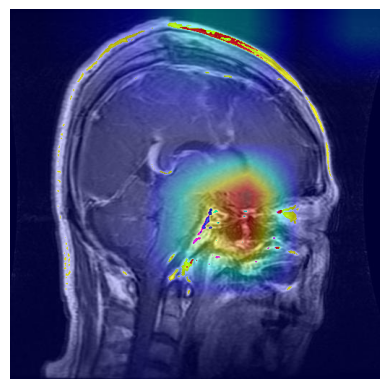

In [17]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("brain_tumor_model.h5")

# Corrected img_path based on the `!ls -R` output, using an existing file name
img_path = "/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_10.jpg"

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)/255.0

# Adjust 'conv5_block3_out' to a valid layer name in your ResNet50 model
# If this layer name is not found, you might need to inspect model.summary() to find a suitable convolutional layer output.
# A common choice for the last convolutional layer in ResNet50 is 'conv5_block3_out' or similar.
# For the Keras ResNet50 application, 'conv5_block3_out' is generally correct for the output of the last convolutional block.
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer("conv5_block3_out").output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_idx = np.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

# Read the original image again for superimposition using cv2
original_img = cv2.imread(img_path)
# Ensure original_img is not None (i.e., image was loaded successfully)
if original_img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}. Please check the path and file integrity.")

# Resize heatmap to the original image dimensions for superimposition
heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + original_img

cv2.imwrite("gradcam.jpg", superimposed_img)

plt.imshow(cv2.cvtColor(np.uint8(superimposed_img), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [19]:
!pip install matplotlib-venn

In [20]:
!apt-get -qq install -y libfluidsynth1

E: Package 'libfluidsynth1' has no installation candidate


In [21]:
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.6_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.6) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.6) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 1.7 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=be0adb5eb3514581f6fe49a1a9cd775e1fc0ea69e9f555119bf9fa50ff034e3d
  Stored in directory: /root/.cache/pip/wheels/29/20/ab/f101da7b245b996aa097685ef742243725ea6150f5b3b6d9ed
Successfully built libarchive


In [22]:
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot

In [23]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 29.2 MB/s eta 0:00:00


In [33]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("brain_tumor_model.h5")

classes = ['glioma','meningioma','notumor','pituitary']

st.title("Brain Tumor Detection")

uploaded_file = st.file_uploader("Upload MRI Image")

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image)

    image = image.resize((224,224))
    image = np.array(image)/255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    st.write("Prediction:", classes[np.argmax(prediction)])

2026-05-12 21:24:19.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.884 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:24:19.887 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [40]:
pip install streamlit


In [45]:
import streamlit as st
import pandas as pd
import tensorflow as tf
import numpy as np
from PIL import Image

st.write("""
# My first app
Hello *world!*
""")

# The previous error was due to trying to read a Keras model file (.h5)
# as a CSV. The file '/content/brain_tumor_model.h5.csv' does not exist.
# If you intended to load the model for predictions, here's how you would load it:

# model = tf.keras.models.load_model("brain_tumor_model.h5")

# If you want to display some data, you need to provide a valid CSV file.
# For now, I'm commenting out the problematic line.

# df = pd.read_csv("/content/brain_tumor_model.h5.csv") # This line caused the error
# st.line_chart(df)

2026-05-12 21:33:32.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:33:32.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:33:32.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [47]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("brain_tumor_model.h5")

classes = ['glioma','meningioma','notumor','pituitary']

st.title("Brain Tumor Detection")

uploaded_file = st.file_uploader("Upload MRI Image")

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image)

    image = image.resize((224,224))
    image = np.array(image)/255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    st.write("Prediction:", classes[np.argmax(prediction)])


Overwriting app.py


In [57]:
import streamlit as st
import pandas as pd

st.write("""
# My first app
Hello *world!*
""")

# The previous error was due to trying to read a non-existent CSV file.
# If you have a CSV file you wish to display, ensure its correct path.
# For now, I'm commenting out the problematic lines.

# df = pd.read_csv("Brain Tumor MRI.csv")
# st.line_chart(df)

2026-05-12 21:43:37.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:43:37.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 21:43:37.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-12 21:50:45.632 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.194.211.35:8501

